用 osmnx 这个库,从 OpenStreetMap(世界上最大的开放地图数据库)下载上海徐汇区所有可步行的街道,变成一个图(graph)。

### OpenStreetMap(OSM)是什么?
世界的"维基百科版地图"——全球志愿者一起标注的免费地图数据。你打开 openstreetmap.org 就能看到。Google 地图是公司的私有数据,而 OSM 是开放的,任何人都能下载用。

### osmnx 干什么?
**自动帮你完成"下载OSM数据 → 转成图结构"**的整个过程。你只需要一行代码,它处理所有脏活。


In [2]:
# install packages
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

print("✅Successfully downloaded all packages.")
print(f"osmnx version: {ox.__version__}")

✅Successfully downloaded all packages.
osmnx version: 2.1.0


In [12]:
# Download Xuhui District map data
# ox.graph_from_place() will automatically download the map data from OpenStreetMap and create a graph object.
# 
import os


def download_map_data():
    graph_path = "data/xuhui_jingan_walk.graphml"
    
    if os.path.exists(graph_path):
        print("✅ Map data already exists. Loading from cache...")
        G = ox.load_graphml(graph_path)
        print('✅ Loaded from cache in seconds')
    else:
        print("❌ Cache not found. Downloading from OSM (2-5 minutes)...")
        places = ["Xuhui District, Shanghai, China", "Jing'an District, Shanghai, China"]
        G = ox.graph_from_place(places, network_type='walk')
        os.makedirs("data", exist_ok=True)
        ox.save_graphml(G, graph_path)
        print('✅ Download complete!')

    return G        



G = download_map_data()   
print(f"Number of nodes:{len(G.nodes)}")
print(f"Number of edges:{len(G.edges)}")

✅ Map data already exists. Loading from cache...
✅ Loaded from cache in seconds
Number of nodes:8314
Number of edges:23860


In [20]:
# check the parameters and methods of the graph nodes:
help(G.nodes)

Help on NodeView in module networkx.classes.reportviews object:

class NodeView(collections.abc.Mapping, collections.abc.Set)
 |  NodeView(graph)
 |  
 |  A NodeView class to act as G.nodes for a NetworkX Graph
 |  
 |  Set operations act on the nodes without considering data.
 |  Iteration is over nodes. Node data can be looked up like a dict.
 |  Use NodeDataView to iterate over node data or to specify a data
 |  attribute for lookup. NodeDataView is created by calling the NodeView.
 |  
 |  Parameters
 |  ----------
 |  graph : NetworkX graph-like class
 |  
 |  Examples
 |  --------
 |  >>> G = nx.path_graph(3)
 |  >>> NV = G.nodes()
 |  >>> 2 in NV
 |  True
 |  >>> for n in NV:
 |  ...     print(n)
 |  0
 |  1
 |  2
 |  >>> assert NV & {1, 2, 3} == {1, 2}
 |  
 |  >>> G.add_node(2, color="blue")
 |  >>> NV[2]
 |  {'color': 'blue'}
 |  >>> G.add_node(8, color="red")
 |  >>> NDV = G.nodes(data=True)
 |  >>> (2, NV[2]) in NDV
 |  True
 |  >>> for n, dd in NDV:
 |  ...     print((n, d

In [28]:
# 1. check the data type of G.nodes 
print("\n--- type ofG.nodes  ---")
print(type(G.nodes))

# 2. check the first 5 nodes:
print("\n--- first 5 nodes id---")
print(list(G.nodes)[:5]) 

print("\n--- first 5 nodes with attributes---")
print(list(G.nodes(data=True))[:5])  # print the first 5 nodes with their attributes

# 3. check the type of single node id:
first_id = list(G.nodes)[0]
print("\n--- type of single node id ---")
print(type(first_id), "->", first_id)

# 4. Check what attributes are attached to a node. 
# OSMnx usually adds attributes such as x and y coordinates.
print("\n--- the attribute of first node")
print(G.nodes[first_id])

# 5. get id and attributes at the same time
print("\n---the first three nodes + attributes---")
for osmid, data in list(G.nodes(data=True))[:3]:
    print(osmid, data)


--- type ofG.nodes  ---
<class 'networkx.classes.reportviews.NodeView'>

--- first 5 nodes id---
[63279232, 63279267, 63283237, 63283241, 63283246]

--- first 5 nodes with attributes---
[(63279232, {'y': 31.2630385, 'x': 121.457487, 'street_count': 3}), (63279267, {'y': 31.2459796, 'x': 121.4576061, 'street_count': 1}), (63283237, {'y': 31.2376933, 'x': 121.4556172, 'highway': 'traffic_signals', 'street_count': 5}), (63283241, {'y': 31.2354854, 'x': 121.4529027, 'street_count': 4}), (63283246, {'y': 31.2346134, 'x': 121.4491054, 'street_count': 4})]

--- type of single node id ---
<class 'int'> -> 63279232

--- the attribute of first node
{'y': 31.2630385, 'x': 121.457487, 'street_count': 3}

---the first three nodes + attributes---
63279232 {'y': 31.2630385, 'x': 121.457487, 'street_count': 3}
63279267 {'y': 31.2459796, 'x': 121.4576061, 'street_count': 1}
63283237 {'y': 31.2376933, 'x': 121.4556172, 'highway': 'traffic_signals', 'street_count': 5}


In [35]:
# 1. check the data type of G.edges 
print("\n--- type ofG.edges  ---")
print(type(G.edges))

# 2. check the first 5 edges:
print("\n--- first 5 edges ---")
print(list(G.edges)[:5]) 

print("\n--- first 5 edges with attributes---")
print(list(G.edges(data=True))[:5])  # print the first 5 edges with their attributes

print("\n--- first 5 edges with attributes---")
print(list(G.edges(keys=True,data=True))[:5])  # print the first 5 edges with their attributes



--- type ofG.edges  ---
<class 'networkx.classes.reportviews.OutMultiEdgeView'>

--- first 5 edges ---
[(63279232, 1723132702, 0), (63279232, 600569894, 0), (63279232, 109758877, 0), (63279267, 648620800, 0), (63283237, 109429793, 0)]

--- first 5 edges with attributes---
[(63279232, 1723132702, {'osmid': [10357483, 85729917, 160265597], 'bridge': 'yes', 'highway': 'trunk_link', 'lanes': '3', 'oneway': False, 'reversed': False, 'length': 467.39251747460133, 'geometry': <LINESTRING (121.457 31.263, 121.457 31.263, 121.457 31.263, 121.457 31.263,...>}), (63279232, 600569894, {'osmid': [10673273, 85729917, 11947111], 'bridge': 'yes', 'highway': ['trunk', 'trunk_link'], 'lanes': '3', 'oneway': False, 'reversed': [False, True], 'length': 636.0393391390421, 'name': '内环高架路', 'geometry': <LINESTRING (121.457 31.263, 121.458 31.263, 121.459 31.264, 121.458 31.263,...>}), (63279232, 109758877, {'osmid': [160265600, 160253765, 160265599], 'bridge': 'yes', 'highway': 'trunk_link', 'lanes': '2', '

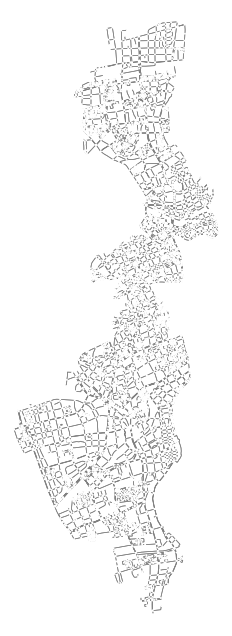

In [36]:
# draw streets network of the downloaded map data

fig, ax = ox.plot_graph(
    G,
    node_size=2,        # set node size to 2 for better visibility
    edge_color='gray',  # set edge color to gray for better contrast against the white background
    edge_linewidth=0.5, # set edge line width to 0.5 for better visibility
    bgcolor='white'     # set background color to white
)

In [41]:
# Compute the first shortest path
# Compute a real shortest path on actual city data and visualize it on the map.
# This will involve using a graph algorithm like Dijkstra's to find the shortest path 
# between two points in the city and then plotting that path on a map. 
# We will use the NetworkX's Dijkstra's algorithm implementation first as a baseline to test
# the precision of my Dijkstra's algorithm implementation.

# Note: the start and end points we are looking for are actually nodes in the graph 
#— not latitude and longitude coordinates, but integer IDs assigned by OSM to each intersection.

# Select two test points and find the nearest nodes using their latitude and longitude coordinates.
# We'll use famouse landmarks in the French Concession area

# point A: Wukang Mansion (武康大楼) - iconic Art Deco building
origin_lat, origin_lon = 31.20467, 121.43856

# Point B: Anfu Road / Wulumuqi Road intersection (安福路 × 乌鲁木齐中路)
dest_lat, dest_lon = 31.21471, 121.446

# Find the nearest nodes to these coordinates in the graph
# (Real GPS coords ---nearest OSM intersection ID)
origin_node = ox.distance.nearest_nodes(G, X=origin_lon, Y=origin_lat)

dest_node = ox.distance.nearest_nodes(G, X=dest_lon, Y=dest_lat)

print(f"Origin node ID:     {origin_node}")

print(f"Destination node ID: {dest_node}")

Origin node ID:     603891428
Destination node ID: 12336555510


In [45]:
# Compute the shortest path using NetworkX's built-in Dijkstra 
# Weight = 'length' means we minimize total street length (meters)

route = nx.shortest_path(
    G,
    source = origin_node,
    target = dest_node,
    weight = 'length' # use edge length (meters) as the cost
)

# How long is the path?
route_length = nx.shortest_path_length(
    G,
    source = origin_node,
    target = dest_node,
    weight = 'length'
)

print(f"Number of nodes in the route: {len(route)}")
print(f"Total length of the route: {route_length: .0f} meters")
print(f"Estimated walking time: {route_length/80:.1f} minutes")  # avg walk 80 m/min




Number of nodes in the route: 17
Total length of the route:  1568 meters
Estimated walking time: 19.6 minutes


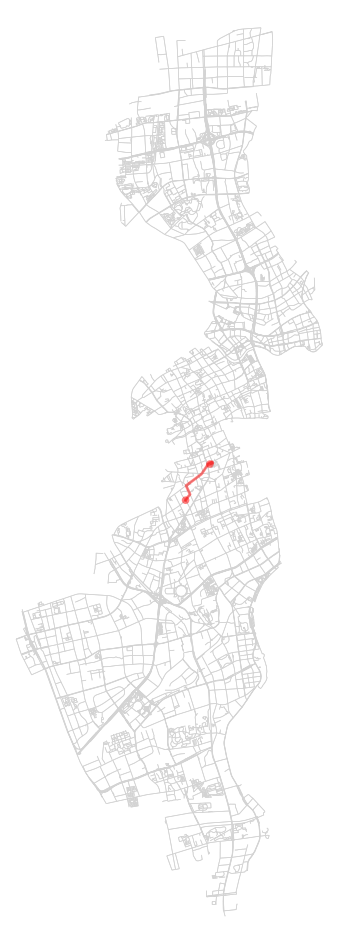

In [48]:
# plot the route on the map

fig, ax = ox.plot_graph_route(
    G,
    route,
    route_color ='red',
    route_linewidth=2,
    node_size=0,      # hide intersection dots for cleaner view
    edge_color='lightgrey',   # streets in light gray
    edge_linewidth = 0.5,
    bgcolor='white',
    orig_dest_size=30,  # ← 起点终点圆点的大小(默认 100,改小)
    figsize=(12,12),  # ← 画布尺寸,单位是英寸(默认大概 8x8)
    dpi=300  # ← 每英寸像素数(默认 100,调到 200 或 300 更清晰)
)

In [ ]:
#check the graph adapter and the accuracy of Dijkstra algorithm I wrote.

# 1. first step: basic check
import logging

logging.basicConfig(level=logging.INFO)

from src.graph_adapter import nx_to_weighted_digraph

wg, osmid_to_node = nx_to_weighted_digraph(G, strict=False)

# check nodes
print(f"NX number of nodes: {G.number_of_nodes()}")
print(f"WG number of nodes: {len(wg.edges)}") # notes weightedgraph only has two objects: edges and weights, no separate nodes list
print(f"the size of the mapping dict: {len(osmid_to_node)}") 
print()

# check edges
nx_unique_edges = len(set((u,v) for u,v in G.edges())) 
wg_edge_count = sum(len(children) for children in wg.edges.values())
print(f"NX unique edges: {nx_unique_edges}")
print(f"WG number of edges: {wg_edge_count}")
print(f"WG the size of weights dict: {len(wg.weights)}")

# 1. we expect the number of nodes in the weighted graph to 
# be equal to the number of unique nodes in the original graph, 
# 2. we expect the number of edges in the weighted graph to be 
# equal to the number of unique edges in the original graph, 
# since we are treating parallel edges as a single edge with 
# the minimum weight.
# 3. we also expect the size of the mapping dict to 
# be equal to the sum of the length of the adjacency list of the 
# weighted graph.

INFO:src.graph_adapter:Converting graph: 8314 nodes, 23860 edges (weight_attr='length', strict=False)
INFO:src.graph_adapter:Conversion complete: in 0.065s (0 edges skipped).


NX number of nodes: 8314
WG number of nodes: 8314
the size of the mapping dict: 8314

NX unique edges: 23477
WG number of edges: 23477
WG the size of weights dict: 23477


In [51]:
# 2. second step: randomly select one pair of nodes and compare
# the build-in Dijkstra's path with the path from 
# my Dijkstra's implementation.

from src.Dijkstra import Dijkstra

import random

# Randomly choose two nodes from the original graph
random.seed(42) # fix the random seed for reproducibility

osmid_list = list(G.nodes)

start_osmid, end_osmid = random.sample(osmid_list, 2)

print(f"start OSM ID: {start_osmid}")
print(f"end OSM ID: {end_osmid}")
print()

# ----use networkx built-in Dijkstra's algorithm to find the shortest path and its length----

try:
    nx_path = nx.shortest_path(G,
                               start_osmid,
                               end_osmid,
                               weight='length')
    
    nx_distance = nx.shortest_path_length(G,
                                          start_osmid,
                                          end_osmid,
                                          weight='length')
    
    print(f"NX distance: {nx_distance: .2f} meters")
    print(f"NX path: {len(nx_path)} nodes")

except nx.NetworkXNoPath:
    print("NX: No path found between the selected nodes.")
    nx_distance, nx_path = None, None


# ---use my Dijkstra's implementation to find the shortest path and its length---

start_node = osmid_to_node[start_osmid]
end_node = osmid_to_node[end_osmid]

my_distance, my_path = Dijkstra(wg, start_node, end_node)

if my_distance is None:
    print("My Dijkstra: No path found between the selected nodes.")
else:
    print(f"my distance: {my_distance: .2f} meters")
    print(f"my path: {len(my_path)} nodes")

# --- comparison ---

print()
if nx_distance is not None and my_distance is not None:
    distance_diff = abs(nx_distance -my_distance)
    print(f"distance difference: {distance_diff: .4f} meters")
    if distance_diff < 0.01:
        print("")
    else:
        print("Warning: distance difference is larger than expected!")

start OSM ID: 1716480834
end OSM ID: 477422994

NX distance:  2494.94 meters
NX path: 26 nodes
my distance:  2494.94 meters
my path: 26 nodes

distance difference:  0.0000 meters



In [52]:
# 3. third step: Multiple random tests (more robust)

# Randomly choose 20 nodes from the original graph
random.seed(42) # fix the random seed for reproducibility

matches = 0
tests = 20

for i in range(tests):
    start_osmid, end_osmid = random.sample(osmid_list, 2)

    try:
        nx_distance = nx.shortest_path_length(G,
                                          start_osmid,
                                          end_osmid,
                                          weight='length')
    
    except nx.NetworkXNoPath:
        continue # skip if no path exists in the original graph


    # ---use my Dijkstra's implementation to find the shortest path and its length---

    start_node = osmid_to_node[start_osmid]
    end_node = osmid_to_node[end_osmid]

    my_distance, my_path = Dijkstra(wg, start_node, end_node)

    if my_distance is None:
        print(f"Test {i+1}: My Dijkstra: No path found between the selected nodes. vs Nx has path with distance {nx_distance: .2f} meters")
        continue


    if abs(nx_distance - my_distance) < 0.01:
        matches += 1
    
    else:
        print(f" Test {i+1}: NX={nx_distance: .2f}, mine={my_distance: .2f} -> distance difference: {abs(nx_distance - my_distance): .4f} meters")

print(f"\n通过率:{matches}/{tests}")



通过率:20/20
